### Customer Churn Prediction and Retention Targeting System

#### Life Cycle of Machine Learning Project

- Understanding the Problem Statement
- Data Collection
- Data Quality Checks
- Exploratory Data Analysis (EDA)
- Data Integration
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Churn Prediction
- Revenue-at-Risk Analysis
- Retention Offer Recommendation
- Campaign Targeting File Generation

---

### 1) Problem Statement

The objective of this project is to build an end-to-end Customer Churn Prediction and Retention Targeting System that identifies customers who are likely to churn and recommends suitable retention strategies. The system integrates customer demographics, engagement metrics, RFM scores, support ticket history, order transactions, billing information, and historical campaign responses to predict churn probability, estimate revenue at risk, and generate campaign-ready retention recommendations.

---

### 2) Data Collection

The project consists of eight synthetic datasets representing different aspects of customer behavior and business operations.

| Dataset | Description |
|----------|-------------|
| customers.csv | Customer demographic and account information |
| customer_churn.csv | Customer churn labels and behavioral attributes (Target Dataset) |
| customer_engagement_metrics.csv | Customer engagement statistics such as logins, sessions, and feature usage |
| support_tickets.csv | Customer support interactions, ticket status, and escalations |
| orders.csv | Customer purchase history and transaction details |
| campaign_responses.csv | Historical marketing campaign responses and offer acceptance |
| subscription_billing.csv | Subscription plans, billing information, and payment history |

The combined datasets provide a comprehensive view of customer behavior for churn prediction and retention analysis.

| **Stage**                                        | **Dataset(s)**                                                                                                                                                                                                               | **Purpose**                                                                                                                                                                    |
| ------------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Data Loading & Cleaning**                      | **customers.csv**, **customer_churn.csv**, **customer_engagement_metrics.csv**,  **orders.csv**, **campaign_responses.csv**, **subscription_billing.csv**                      | Load all datasets, handle missing values, remove duplicates, validate data types, and prepare clean data for processing.                                                       |
| **Feature Engineering**                          | **customers.csv**, **customer_engagement_metrics.csv**, **subscription_billing.csv** *(optional)*                                                                             | Create ML-ready features such as tenure, days since last login, engagement metrics, RFM scores, complaint counts, escalations, payment failures, and billing-related features. |
| **ML Model Training**                            | **customer_churn.csv** *(target: `churned`)* + engineered features from **customers.csv**, **customer_engagement_metrics.csv** and **subscription_billing.csv** *(optional)* | Train the churn prediction model using customer profile, behavior, engagement, RFM, and optional billing features.                                                    |
| **Churn Prediction**                             | **Current customer feature dataset**                                                                                                                                                                                         | Predict the churn probability (churn score) for each customer using the trained model.                                                                                         |
| **Revenue Analysis (After Prediction)**          | **orders.csv** + **churn predictions**                                                                                                                                                                                       | Calculate customer lifetime revenue, average order value, and **revenue at risk** for customers predicted to churn.                                                            |
| **Retention Offer Selection (After Prediction)** | **campaign_responses.csv** + **customer_churn.csv** *(retention_offer_sent history)*                                                                                                                                         | Recommend the most suitable retention offer and communication channel based on previous campaign responses and offer history.                                                  |
| **Final Output Generation**                      | **Outputs from Churn Prediction, Revenue Analysis, and Offer Selection**                                                                                                                                                     | Generate a campaign-ready file containing `customer_id`, `churn_score`, `segment`, `revenue_at_risk`, `offer_type`, `channel`, and `expected_value`.                           |



2.1 import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

importing csv datsets 

In [3]:
campaign_responses=pd.read_csv('data/campaign_responses.csv')
customer_churn=pd.read_csv('data/customer_churn.csv')
customer_engagement_metrics=pd.read_csv('data/customer_engagement_metrics.csv')
customers=pd.read_csv('data/customers.csv')
orders=pd.read_csv('data/orders.csv')
subscription_billing=pd.read_csv('data/subscription_billing.csv')


In [4]:
datasets = {
    "Campaign Responses": campaign_responses,
    "Customer Churn": customer_churn,
    "Customer Engagement": customer_engagement_metrics,
    "Customers": customers,
    "Orders": orders,
    "Subscription Billing": subscription_billing,
}


In [5]:
missing_ds = []
duplicate_ds = []

def basic_eda(df, name):
    print("=" * 80)
    print(f"Dataset : {name}")
    print("=" * 80)

    # Basic Information
    print(f"Shape                 : {df.shape}")
    print(f"Memory Usage          : {round(df.memory_usage(deep=True).sum() / (1024**2), 2)} MB")

    # Column Names
    print("\nColumn Names")
    print(df.columns.tolist())

    # Data Types
    print("\nData Types")
    print(df.dtypes)

    # Missing Values
    print("\nMissing Values")
    print(df.isnull().sum())

    total_missing = df.isnull().sum().sum()
    print(f"\nTotal Missing Values  : {total_missing}")

    if total_missing > 0:
        missing_ds.append(name)

    # Duplicate Rows
    duplicates = df.duplicated().sum()
    print(f"Duplicate Rows        : {duplicates}")

    if duplicates > 0:
        duplicate_ds.append(name)

    # Unique Values
    print("\nUnique Values")
    print(df.nunique())

    # Numerical & Categorical Columns
    numerical_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

    print(f"\nNumerical Columns ({len(numerical_cols)})")
    print(numerical_cols)

    print(f"\nCategorical Columns ({len(categorical_cols)})")
    print(categorical_cols)

    # Statistical Summary
    print("\nStatistical Summary")
    print(df.describe().T)

    # Categorical Summary
    if len(categorical_cols) > 0:
        print("\nCategorical Summary")
        print(df[categorical_cols].describe().T)

    print("\n")

In [6]:
for  name,df in datasets.items():
    basic_eda(df,name)

Dataset : Campaign Responses
Shape                 : (578395, 6)
Memory Usage          : 108.11 MB

Column Names
['response_id', 'campaign_id', 'customer_id', 'responded', 'converted', 'revenue']

Data Types
response_id        str
campaign_id        str
customer_id        str
responded        int64
converted        int64
revenue        float64
dtype: object

Missing Values
response_id    0
campaign_id    0
customer_id    0
responded      0
converted      0
revenue        0
dtype: int64

Total Missing Values  : 0
Duplicate Rows        : 0

Unique Values
response_id    578395
campaign_id      5000
customer_id    146833
responded           2
converted           2
revenue        108376
dtype: int64

Numerical Columns (3)
['responded', 'converted', 'revenue']

Categorical Columns (3)
['response_id', 'campaign_id', 'customer_id']

Statistical Summary
              count        mean         std  min     25%    50%    75%     max
responded  578395.0    0.499742    0.500000  0.0    0.00    0.0 

In [7]:
print("=" * 80)
print("EDA SUMMARY")
print("=" * 80)

print("Datasets with Missing Values:")
print(missing_ds if missing_ds else "None")

print("\nDatasets with Duplicate Rows:")
print(duplicate_ds if duplicate_ds else "None")

EDA SUMMARY
Datasets with Missing Values:
['Customers', 'Orders']

Datasets with Duplicate Rows:
None


In [8]:
def missing_value_analysis(name):
    df = datasets[name]

    print("=" * 50)
    print(name)
    print("=" * 50)

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    missing_percent = (missing / len(df)) * 100

    print("Missing Columns")
    print(missing)

    print("\nMissing Percentage")
    print(missing_percent.round(2))

    print("\n" + "=" * 50)
    print(f"Handling Missing Values in {name}")
    print("=" * 50)

    if name == "Customers":
        # Fill country using state mapping
        state_country_map = (
            df.dropna(subset=["country"])
              .drop_duplicates("state")
              .set_index("state")["country"]
        )

        df["country"] = df["country"].fillna(df["state"].map(state_country_map))

        print("Filled missing values in 'country' using 'state' mapping.")

    elif name == "Orders":
        # Fill shipping_country using shipping_state mapping
        state_country_map = (
            df.dropna(subset=["shipping_country"])
              .drop_duplicates("shipping_state")
              .set_index("shipping_state")["shipping_country"]
        )

        df["shipping_country"] = df["shipping_country"].fillna(
            df["shipping_state"].map(state_country_map)
        )

        # promo_code: missing means no promo code used
        df["promo_code"] = df["promo_code"].fillna("No Promo")

        print("Filled 'shipping_country' using 'shipping_state' mapping.")
        print("Filled 'promo_code' with 'No Promo'.")

    print("\nRemaining Missing Values")
    print(df.isnull().sum()[df.isnull().sum() > 0])

    datasets[name] = df


for name in missing_ds:
    missing_value_analysis(name)

Customers
Missing Columns
country    469
dtype: int64

Missing Percentage
country    0.5
dtype: float64

Handling Missing Values in Customers
Filled missing values in 'country' using 'state' mapping.

Remaining Missing Values
Series([], dtype: int64)
Orders
Missing Columns
shipping_country      573
promo_code          28616
dtype: int64

Missing Percentage
shipping_country     0.50
promo_code          25.02
dtype: float64

Handling Missing Values in Orders
Filled 'shipping_country' using 'shipping_state' mapping.
Filled 'promo_code' with 'No Promo'.

Remaining Missing Values
Series([], dtype: int64)


### Integrating data sets

![ChatGPT Image Aug 5, 2026, 12_11_22 PM.png](<attachment:ChatGPT Image Aug 5, 2026, 12_11_22 PM.png>)
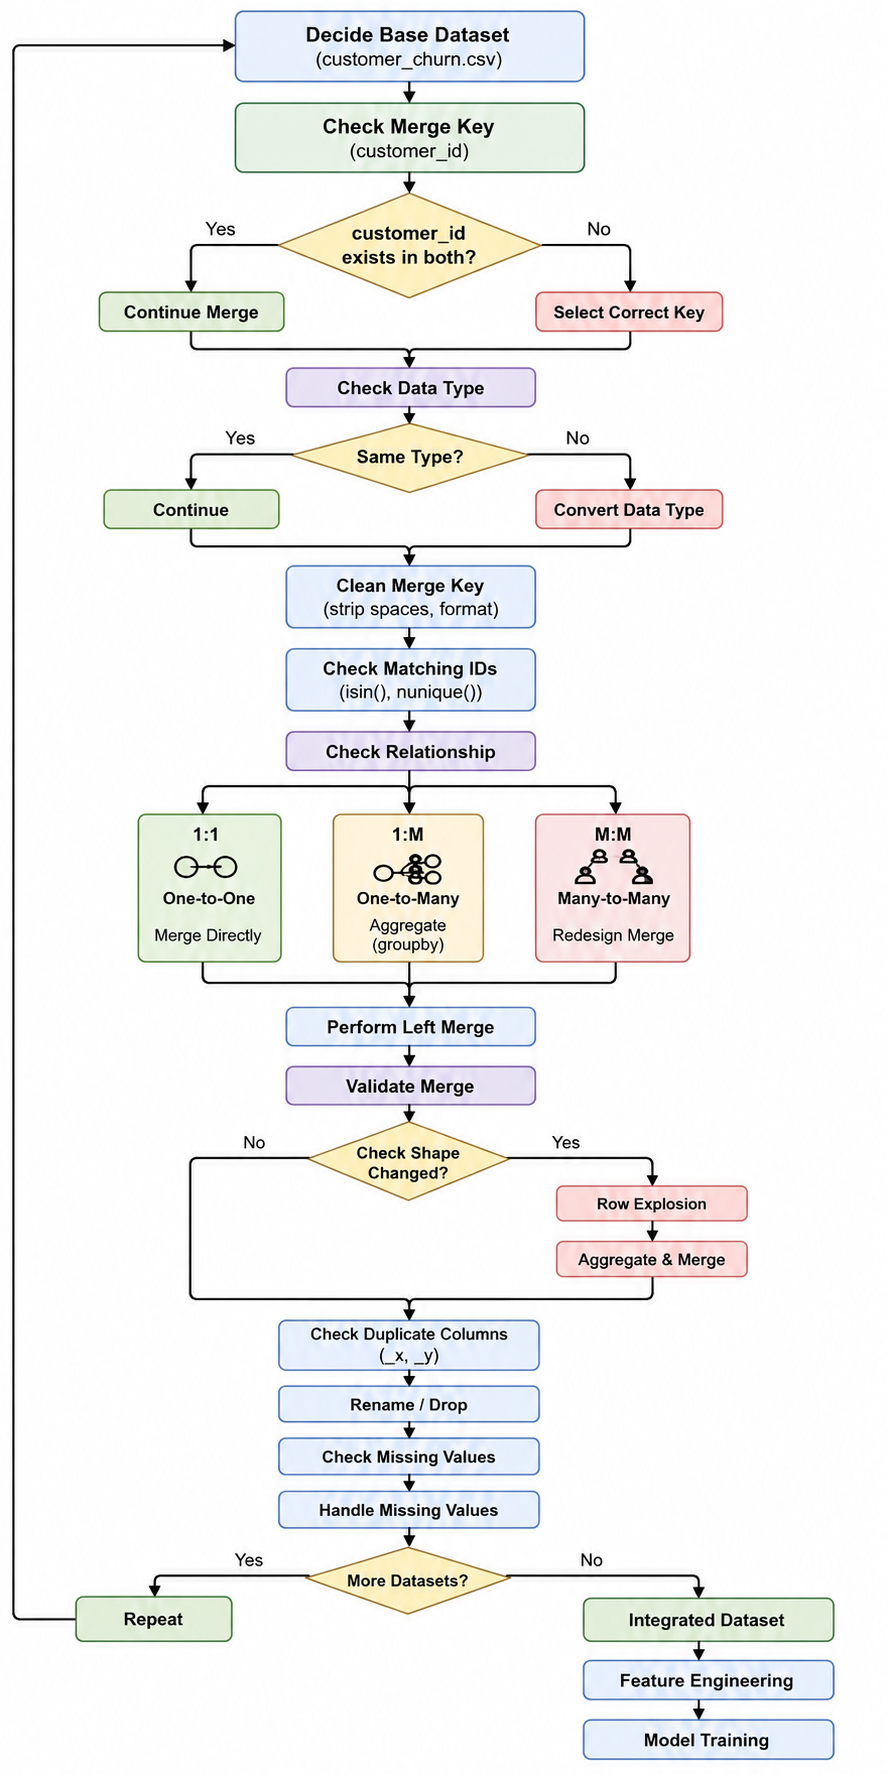

In [9]:
#step 1 
# Checking merge key and datatype
# Selected customer_churn as the base dataset because it contains the target column.

fix_keys = {}
fix_types = {}

base_key = "customer_id"
base_type = customer_churn[base_key].dtype

for name, df in datasets.items():

    # Check if merge key exists
    if base_key not in df.columns:
        fix_keys[name] = df

    # Check datatype of merge key
    elif df[base_key].dtype != base_type:
        fix_types[name] = df
    


In [10]:
print("="*60)
print("MERGE KEY VALIDATION SUMMARY")
print("="*60)
if len(fix_keys) == 0:
    print("All datasets contain the merge key (customer_id).")
else:
    print("Datasets missing merge key:")
    print(list(fix_keys.keys()))

if len(fix_types) == 0:
    print("\nAll datasets have the same data type for customer_id.")
else:
    print("\nDatasets with incorrect data type:")
    print(list(fix_types.keys()))

MERGE KEY VALIDATION SUMMARY
All datasets contain the merge key (customer_id).

All datasets have the same data type for customer_id.


In [11]:
# step 2 
# Clean Merge Key
# in ouput i got all customer id values are same length so no strip etc needed
for name, df in datasets.items():
    print("=" * 50)
    print(name)
    print("=" * 50)

    print(df[base_key].str.len().value_counts().sort_index())
    # print(df[base_key][0])

Campaign Responses
customer_id
7    578395
Name: count, dtype: int64
Customer Churn
customer_id
7    181175
Name: count, dtype: int64
Customer Engagement
customer_id
7    219237
Name: count, dtype: int64
Customers
customer_id
7    93551
Name: count, dtype: int64
Orders
customer_id
7    114387
Name: count, dtype: int64
Subscription Billing
customer_id
7    126941
Name: count, dtype: int64


In [12]:
print("=" * 60)
print("MATCHING CUSTOMER ID ANALYSIS")
print("=" * 60)

base_ids = set(customer_churn["customer_id"])

for name, df in datasets.items():
    print("=" * 50)
    print(name)
    print("=" * 50)

    matching_ids = len(base_ids.intersection(set(df["customer_id"])))

    print("Base Customer IDs       :", len(base_ids))
    print("Matching IDs            :", matching_ids)
    print(f'Total records           : {len(df)}')

MATCHING CUSTOMER ID ANALYSIS
Campaign Responses
Base Customer IDs       : 150000
Matching IDs            : 146833
Total records           : 578395
Customer Churn
Base Customer IDs       : 150000
Matching IDs            : 150000
Total records           : 181175
Customer Engagement
Base Customer IDs       : 150000
Matching IDs            : 150000
Total records           : 219237
Customers
Base Customer IDs       : 150000
Matching IDs            : 93551
Total records           : 93551
Orders
Base Customer IDs       : 150000
Matching IDs            : 80183
Total records           : 114387
Subscription Billing
Base Customer IDs       : 150000
Matching IDs            : 126941
Total records           : 126941


# Observation

1. Customer Engagement and Customer RFM have complete customer coverage (150,000 matching customer IDs), so they can be merged without losing customer information.

2. Customers has only 93,551 matching customer IDs, indicating that customer profile information is unavailable for the remaining customers. These records will contain missing values after the merge.

3. Subscription Billing has 126,941 matching customer IDs, so billing information is unavailable for some customers and will result in missing values after the merge.

4. Orders has only 80,183 matching customer IDs because not every customer has placed an order.

5. Support Tickets has only 72,253 matching customer IDs because not every customer has raised a support ticket.

6. Campaign Responses has 146,833 matching customer IDs, indicating that most customers have campaign history, but some customers do not.

In [13]:
print("=" * 60)
print("RELATIONSHIP ANALYSIS")
print("=" * 60)
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)

    unique_ids = df["customer_id"].nunique()
    total_records = len(df)

    if total_records == unique_ids:
        relationship = "One-to-One"
    else:
        relationship = "One-to-Many"

    print("Relationship      :", relationship)
    print("Total Records     :", total_records)
    print("Unique Customer IDs:", unique_ids)

RELATIONSHIP ANALYSIS
Campaign Responses
Relationship      : One-to-Many
Total Records     : 578395
Unique Customer IDs: 146833
Customer Churn
Relationship      : One-to-Many
Total Records     : 181175
Unique Customer IDs: 150000
Customer Engagement
Relationship      : One-to-Many
Total Records     : 219237
Unique Customer IDs: 150000
Customers
Relationship      : One-to-One
Total Records     : 93551
Unique Customer IDs: 93551
Orders
Relationship      : One-to-Many
Total Records     : 114387
Unique Customer IDs: 80183
Subscription Billing
Relationship      : One-to-One
Total Records     : 126941
Unique Customer IDs: 126941


### handling one to many relationships

In [14]:
customer_churn['updated_at']=pd.to_datetime(customer_churn['updated_at'])
customer_churn=customer_churn.sort_values(by='updated_at')
customer_churn=customer_churn.drop_duplicates(subset='customer_id',keep='last')


In [15]:
#updates in main datsets dict also
datasets["Customer Churn"] = customer_churn

In [16]:
print("No of duplicate custome_id: ",customer_churn['customer_id'].nunique()-len(customer_churn))

No of duplicate custome_id:  0


**Observation:**

The `customer_churn` dataset initially had a **One-to-Many** relationship because some customers had multiple historical records with different `updated_at` values.

To make it suitable as the **base dataset**, the older records for each `customer_id` were removed, keeping only the latest record based on `updated_at`.

After this preprocessing, the `customer_churn` dataset now has a **One-to-One** relationship, with exactly one record for each customer.

###  Customer Engagement 

In [17]:
len(customer_engagement_metrics)


219237

In [18]:
len(customer_engagement_metrics) - customer_engagement_metrics["customer_id"].nunique()

69237

In [19]:
id=customer_engagement_metrics['customer_id'].value_counts().idxmax()
customer_engagement_metrics[customer_engagement_metrics['customer_id']==id]

,metric_id,customer_id,last_login_date,login_frequency_30d,pages_per_session,avg_session_duration_min,mobile_app_usage_pct,email_open_rate,email_click_rate,push_notification_opt_in,nps_score,csat_score,feature_adoption_score,community_forum_posts,referrals_made,support_escalations_90d,product_tours_completed,wishlist_items,cart_abandonment_rate,promo_code_usage_90d,engagement_tier,measured_date
0,ENG00000001,C000001,2025-08-20,6,14.5,39.1,82.8,38.0,18.3,0,7,5,36.0,6,1,4,3,14,0.81,9,medium,2025-08-20
150000,ENG00150001,C000001,2025-09-17,17,10.1,19.8,29.2,32.1,4.3,1,4,5,75.5,19,2,1,5,19,0.32,3,medium,2025-09-17


In [20]:
# handling duplicate customer_id
customer_engagement_metrics['measured_date']=pd.to_datetime(customer_engagement_metrics['measured_date'])
customer_engagement_metrics=customer_engagement_metrics.sort_values(by='measured_date')
customer_engagement_metrics=customer_engagement_metrics.drop_duplicates(subset='customer_id',keep='last')



In [21]:
#updates in main datsets dict also
datasets['Customer Engagement']=customer_engagement_metrics

In [22]:
print("=" * 60)
print("FINAL RELATIONSHIP ANALYSIS")
print("=" * 60)
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)

    unique_ids = df["customer_id"].nunique()
    total_records = len(df)

    if total_records == unique_ids:
        relationship = "One-to-One"
    else:
        relationship = "One-to-Many"

    print("Relationship      :", relationship)
    print("Total Records     :", total_records)
    print("Unique Customer IDs:", unique_ids)

FINAL RELATIONSHIP ANALYSIS
Campaign Responses
Relationship      : One-to-Many
Total Records     : 578395
Unique Customer IDs: 146833
Customer Churn
Relationship      : One-to-One
Total Records     : 150000
Unique Customer IDs: 150000
Customer Engagement
Relationship      : One-to-One
Total Records     : 150000
Unique Customer IDs: 150000
Customers
Relationship      : One-to-One
Total Records     : 93551
Unique Customer IDs: 93551
Orders
Relationship      : One-to-Many
Total Records     : 114387
Unique Customer IDs: 80183
Subscription Billing
Relationship      : One-to-One
Total Records     : 126941
Unique Customer IDs: 126941


In [23]:
# ==========================
# RFM FEATURE ENGINEERING
# ==========================

# Convert order date to datetime
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Reference date (one day after the latest order)
reference_date = orders["order_date"].max() + pd.Timedelta(days=1)

# Create RFM table
customer_rfm = (
    orders.groupby("customer_id")
    .agg(
        recency_days=("order_date", lambda x: (reference_date - x.max()).days),
        frequency=("order_id", "count"),
        monetary=("total_amount", "sum")
    )
    .reset_index()
)

# Calculate R, F and M Scores (1 to 5)
customer_rfm["r_score"] = pd.qcut(
    customer_rfm["recency_days"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

customer_rfm["f_score"] = pd.qcut(
    customer_rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

customer_rfm["m_score"] = pd.qcut(
    customer_rfm["monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Convert scores to integer
customer_rfm["r_score"] = customer_rfm["r_score"].astype(int)
customer_rfm["f_score"] = customer_rfm["f_score"].astype(int)
customer_rfm["m_score"] = customer_rfm["m_score"].astype(int)

# Create RFM Segment
def assign_rfm_segment(row):

    if row["r_score"] >= 4 and row["f_score"] >= 4 and row["m_score"] >= 4:
        return "Champions"

    elif row["r_score"] >= 3 and row["f_score"] >= 3:
        return "Loyal Customers"

    elif row["r_score"] >= 4 and row["f_score"] <= 2:
        return "Promising"

    elif row["r_score"] <= 2 and row["f_score"] >= 4:
        return "At Risk"

    else:
        return "Lost"


customer_rfm["rfm_segment"] = customer_rfm.apply(assign_rfm_segment, axis=1)

display(customer_rfm.head())

,customer_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_segment
0,C000001,119,2,1869.20,4,4,3,Loyal Customers
1,C000004,303,1,1034.75,3,1,2,Lost
2,C000005,183,1,1049.50,4,1,2,Promising
3,C000006,279,1,1403.75,3,1,3,Lost
4,C000007,276,1,2314.72,3,1,4,Lost


# Observation

- RFM features were created from the `orders.csv` dataset.
- For each customer, the following features were calculated:
  - **Recency**: Number of days since the customer's most recent order.
  - **Frequency**: Total number of orders placed by the customer.
  - **Monetary**: Total amount spent by the customer.
- R, F, and M scores were calculated using quintile-based ranking (`qcut`).
- Customers were then assigned to RFM segments based on their R, F, and M scores.
- The final RFM dataset contains one record per customer and is ready for integration with the training dataset.

In [24]:
def integrate_datasets():

    integrated_df = customer_churn.copy()

    integrated_df = integrated_df.merge(
        customers,
        on="customer_id",
        how="left"
    )

    integrated_df = integrated_df.merge(
        customer_engagement_metrics,
        on="customer_id",
        how="left"
    )

    integrated_df = integrated_df.merge(
        customer_rfm,
        on="customer_id",
        how="left"
    )

    integrated_df = integrated_df.merge(
        subscription_billing,
        on="customer_id",
        how="left"
    )

    return integrated_df

In [25]:
integrated_df = integrate_datasets()
display(integrated_df.head())

,customer_id,tenure_months_x,contract_type_x,monthly_spend,days_since_last_order,support_tickets_30d,total_spend,order_count,avg_order_value,payment_method_x,autopay,num_products_owned,complaint_count,nps_score_x,satisfaction_score,churned,churn_reason,predicted_churn_prob,retention_offer_sent,offer_accepted,last_contact_date,account_manager_x,updated_at_x,email,name,first_name,last_name,country,state,city,street_address,postal_code,signup_date,age,gender,occupation,marital_status,household_size,segment,lifetime_value,loyalty_points,preferred_channel,preferred_language,phone,account_status,referral_source,email_opt_in,sms_opt_in,last_login_date_x,created_at_x,metric_id,last_login_date_y,login_frequency_30d,pages_per_session,avg_session_duration_min,mobile_app_usage_pct,email_open_rate,email_click_rate,push_notification_opt_in,nps_score_y,csat_score,feature_adoption_score,community_forum_posts,referrals_made,support_escalations_90d,product_tours_completed,wishlist_items,cart_abandonment_rate,promo_code_usage_90d,engagement_tier,measured_date,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_segment,billing_id,plan_name,contract_type_y,monthly_recurring_revenue,annual_contract_value,billing_cycle,payment_method_y,autopay_enabled,paperless_billing,late_payments_12m,price_increase_last_year,discount_pct,tenure_months_y,contract_end_date,payment_failures_90d,billing_address_city,tax_exempt,invoice_delivery,account_manager_y,created_at_y,updated_at_y
0,C135481,65,annual,132.82,223,9,9670.8,12,322.36,credit_card,0,3,2,1,1,1,competitor,0.869,email,0,2025-07-11,Amanda Bennett,2025-06-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENG00135481,2025-11-02,1,14.1,4.7,19.6,9.1,1.5,0,10,2,25.8,12,2,2,10,17,0.37,9,low,2025-11-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C123396,53,annual,286.50,6,0,22844.1,76,761.47,ach,1,3,2,9,3,0,none,0.332,sms,1,2026-06-03,Laura Gilbert,2025-06-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENG00123396,2026-06-09,2,11.3,42.9,84.3,56.8,11.7,1,7,2,58.8,10,7,1,8,5,0.89,3,high,2026-06-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BIL00123396,Grass-roots asynchronous extranet,biennial,177.13,2039.25,annual,ach,1.0,1.0,2.0,0.0,14.7,9.0,2025-09-22,0.0,North Hollyfurt,0.0,mail,Jeffrey Romero,2025-02-13,2026-06-09
2,C143195,46,biennial,65.39,2,0,3891.6,41,129.72,invoice,0,5,2,9,4,0,none,0.251,email,1,2026-05-11,Michelle Mcdonald,2025-06-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENG00143195,2026-02-13,24,9.2,16.0,20.3,45.0,5.3,0,10,3,62.0,17,5,0,10,15,0.06,3,high,2026-02-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C125230,87,annual,55.78,322,4,3067.8,14,102.26,invoice,1,7,3,6,2,1,competitor,0.732,call,0,2025-06-25,Joseph Rice,2025-06-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENG00125230,2026-03-24,29,8.8,6.1,48.4,35.0,13.1,0,7,4,29.5,12,1,0,9,28,0.38,6,dormant,2026-03-24,425.0,1.0,1411.97,2.0,3.0,3.0,Lost,BIL00125230,Persevering holistic function,annual,162.51,1856.50,monthly,paypal,1.0,1.0,0.0,1.0,5.1,84.0,2026-05-14,0.0,South Allisonview,0.0,mail,Michele Ford,2023-12-30,2026-03-24
4,C034584,2,annual,269.11,27,4,21353.4,78,711.78,credit_card,0,1,1,10,5,0,none,0.038,sms,0,2025-08-23,Jordan Wall,2025-06-23,pamela52@example.com,Ryan Mcclain,Lisa,Wilson,CA,MA,Lake Craigburgh,50938 Deborah Plaza,30744.0,2023-08-20,52.0,Other,Chartered certified accountant,widowed,6.0,Gold,3858.25,4597.0,web,de,277-799-1898,suspended,paid_ads,0.0,1.0,2025-09-03,2023-08-20,ENG00184584,2026-05-12,19,5.3,39.8,78.0,70.8,14.9,0,8,5,73.0,11,0,0,8,3,0.37,13,dormant,2026-05-12,74.0,1.0,2307.43,5.0,1.0,4.0,Promising,BIL00034584,Virtual optimal hard

In [26]:
integrated_df.shape

(150000, 99)

In [27]:
integrated_df.columns

Index(['customer_id', 'tenure_months_x', 'contract_type_x', 'monthly_spend',
       'days_since_last_order', 'support_tickets_30d', 'total_spend',
       'order_count', 'avg_order_value', 'payment_method_x', 'autopay',
       'num_products_owned', 'complaint_count', 'nps_score_x',
       'satisfaction_score', 'churned', 'churn_reason', 'predicted_churn_prob',
       'retention_offer_sent', 'offer_accepted', 'last_contact_date',
       'account_manager_x', 'updated_at_x', 'email', 'name', 'first_name',
       'last_name', 'country', 'state', 'city', 'street_address',
       'postal_code', 'signup_date', 'age', 'gender', 'occupation',
       'marital_status', 'household_size', 'segment', 'lifetime_value',
       'loyalty_points', 'preferred_channel', 'preferred_language', 'phone',
       'account_status', 'referral_source', 'email_opt_in', 'sms_opt_in',
       'last_login_date_x', 'created_at_x', 'metric_id', 'last_login_date_y',
       'login_frequency_30d', 'pages_per_session', 'avg_se

In [28]:
# =====================================
# REMOVE DUPLICATE COLUMNS
# =====================================

integrated_df.drop(columns=[
    "tenure_months_y",
    "contract_type_y",
    "payment_method_y",
    "account_manager_y",
    "updated_at_y",
    "last_login_date_y",
    "nps_score_y"
], inplace=True)

integrated_df.rename(columns={
    "tenure_months_x": "tenure_months",
    "contract_type_x": "contract_type",
    "payment_method_x": "payment_method",
    "account_manager_x": "account_manager",
    "updated_at_x": "updated_at",
    "last_login_date_x": "last_login_date",
    "nps_score_x": "nps_score"
}, inplace=True)


# =====================================
# REMOVE PERSONAL / IDENTIFIER COLUMNS
# =====================================

integrated_df.drop(columns=[
    "email",
    "name",
    "first_name",
    "last_name",
    "phone",
    "street_address",
    "postal_code",
    "metric_id",
    "billing_id"
], inplace=True)

# =====================================
# UNNECESSARY COLUMNS
# =====================================


integrated_df.drop(columns=[
    "customer_id",
    "account_manager",
    "updated_at",
    "created_at_x",
    "created_at_y",
    "last_contact_date",
    "last_login_date",
    "measured_date",
    "contract_end_date",
    'signup_date'
], inplace=True)
print("Duplicate and personal columns removed successfully.")

Duplicate and personal columns removed successfully.


In [29]:
integrated_df.isna().sum()

tenure_months                    0
contract_type                    0
monthly_spend                    0
days_since_last_order            0
support_tickets_30d              0
total_spend                      0
order_count                      0
avg_order_value                  0
payment_method                   0
autopay                          0
num_products_owned               0
complaint_count                  0
nps_score                        0
satisfaction_score               0
churned                          0
churn_reason                     0
predicted_churn_prob             0
retention_offer_sent             0
offer_accepted                   0
country                      56449
state                        56449
city                         56449
age                          56449
gender                       56449
occupation                   56449
marital_status               56449
household_size               56449
segment                      56449
lifetime_value      

In [30]:
# =====================================
# HANDLE MISSING VALUES
# =====================================

# ---------- Customer Profile ----------

customer_cat_cols = [
    "country", "state", "city", "gender", "occupation",
    "marital_status", "segment", "preferred_channel",
    "preferred_language", "account_status", "referral_source"
]

integrated_df[customer_cat_cols] = integrated_df[customer_cat_cols].fillna("Unknown")


customer_num_cols = [
    "age",
    "household_size",
    "lifetime_value",
    "loyalty_points"
]

for col in customer_num_cols:
    integrated_df[col] = integrated_df[col].fillna(integrated_df[col].median())


integrated_df["email_opt_in"] = integrated_df["email_opt_in"].fillna(0)
integrated_df["sms_opt_in"] = integrated_df["sms_opt_in"].fillna(0)


# ---------- RFM ----------

integrated_df["frequency"] = integrated_df["frequency"].fillna(0)
integrated_df["monetary"] = integrated_df["monetary"].fillna(0)

integrated_df["recency_days"] = integrated_df["recency_days"].fillna(
    integrated_df["recency_days"].max() + 1
)

integrated_df["r_score"] = integrated_df["r_score"].fillna(0)
integrated_df["f_score"] = integrated_df["f_score"].fillna(0)
integrated_df["m_score"] = integrated_df["m_score"].fillna(0)

integrated_df["rfm_segment"] = integrated_df["rfm_segment"].fillna("No Purchase")


# ---------- Subscription Billing ----------

billing_cat_cols = [
    "plan_name",
    "billing_cycle",
    "billing_address_city",
    "invoice_delivery"
]

integrated_df[billing_cat_cols] = integrated_df[billing_cat_cols].fillna("No Plan")


billing_num_cols = [
    "monthly_recurring_revenue",
    "annual_contract_value",
    "late_payments_12m",
    "price_increase_last_year",
    "discount_pct",
    "payment_failures_90d"
]

integrated_df[billing_num_cols] = integrated_df[billing_num_cols].fillna(0)


integrated_df["autopay_enabled"] = integrated_df["autopay_enabled"].fillna(0)
integrated_df["paperless_billing"] = integrated_df["paperless_billing"].fillna(0)
integrated_df["tax_exempt"] = integrated_df["tax_exempt"].fillna(0)


print("Missing values handled successfully.")
print()
print(integrated_df.isna().sum()[integrated_df.isna().sum() > 0])

Missing values handled successfully.

Series([], dtype: int64)


# Observation

- Missing values in customer profile columns were handled using domain-specific strategies:
  - Categorical columns were filled with **"Unknown"**.
  - Numerical columns were filled using the **median**.
  - Boolean columns were filled with **0**.
- Missing RFM values indicate customers with no purchase history. Therefore:
  - `frequency` and `monetary` were filled with **0**.
  - `recency_days` was filled with the maximum recency value plus one.
  - `r_score`, `f_score`, and `m_score` were filled with **0**.
  - `rfm_segment` was filled with **"No Purchase"**.
- Missing subscription billing values indicate customers without a billing record. Numerical columns were filled with **0**, categorical columns with **"No Plan"**, and boolean columns with **0**.
- After preprocessing, the integrated dataset contains no missing values and is ready for feature engineering and model training.

In [31]:
integrated_df.isna().sum().sum()

np.int64(0)

In [32]:
integrated_df.head()

,tenure_months,contract_type,monthly_spend,days_since_last_order,support_tickets_30d,total_spend,order_count,avg_order_value,payment_method,autopay,num_products_owned,complaint_count,nps_score,satisfaction_score,churned,churn_reason,predicted_churn_prob,retention_offer_sent,offer_accepted,country,state,city,age,gender,occupation,marital_status,household_size,segment,lifetime_value,loyalty_points,preferred_channel,preferred_language,account_status,referral_source,email_opt_in,sms_opt_in,login_frequency_30d,pages_per_session,avg_session_duration_min,mobile_app_usage_pct,email_open_rate,email_click_rate,push_notification_opt_in,csat_score,feature_adoption_score,community_forum_posts,referrals_made,support_escalations_90d,product_tours_completed,wishlist_items,cart_abandonment_rate,promo_code_usage_90d,engagement_tier,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_segment,plan_name,monthly_recurring_revenue,annual_contract_value,billing_cycle,autopay_enabled,paperless_billing,late_payments_12m,price_increase_last_year,discount_pct,payment_failures_90d,billing_address_city,tax_exempt,invoice_delivery
0,65,annual,132.82,223,9,9670.8,12,322.36,credit_card,0,3,2,1,1,1,competitor,0.869,email,0,Unknown,Unknown,Unknown,46.0,Unknown,Unknown,Unknown,3.0,Unknown,12269.50,24971.0,Unknown,Unknown,Unknown,Unknown,0.0,0.0,1,14.1,4.7,19.6,9.1,1.5,0,2,25.8,12,2,2,10,17,0.37,9,low,732.0,0.0,0.00,0.0,0.0,0.0,No Purchase,No Plan,0.00,0.00,No Plan,0.0,0.0,0.0,0.0,0.0,0.0,No Plan,0.0,No Plan
1,53,annual,286.50,6,0,22844.1,76,761.47,ach,1,3,2,9,3,0,none,0.332,sms,1,Unknown,Unknown,Unknown,46.0,Unknown,Unknown,Unknown,3.0,Unknown,12269.50,24971.0,Unknown,Unknown,Unknown,Unknown,0.0,0.0,2,11.3,42.9,84.3,56.8,11.7,1,2,58.8,10,7,1,8,5,0.89,3,high,732.0,0.0,0.00,0.0,0.0,0.0,No Purchase,Grass-roots asynchronous extranet,177.13,2039.25,annual,1.0,1.0,2.0,0.0,14.7,0.0,North Hollyfurt,0.0,mail
2,46,biennial,65.39,2,0,3891.6,41,129.72,invoice,0,5,2,9,4,0,none,0.251,email,1,Unknown,Unknown,Unknown,46.0,Unknown,Unknown,Unknown,3.0,Unknown,12269.50,24971.0,Unknown,Unknown,Unknown,Unknown,0.0,0.0,24,9.2,16.0,20.3,45.0,5.3,0,3,62.0,17,5,0,10,15,0.06,3,high,732.0,0.0,0.00,0.0,0.0,0.0,No Purchase,No Plan,0.00,0.00,No Plan,0.0,0.0,0.0,0.0,0.0,0.0,No Plan,0.0,No Plan
3,87,annual,55.78,322,4,3067.8,14,102.26,invoice,1,7,3,6,2,1,competitor,0.732,call,0,Unknown,Unknown,Unknown,46.0,Unknown,Unknown,Unknown,3.0,Unknown,12269.50,24971.0,Unknown,Unknown,Unknown,Unknown,0.0,0.0,29,8.8,6.1,48.4,35.0,13.1,0,4,29.5,12,1,0,9,28,0.38,6,dormant,425.0,1.0,1411.97,2.0,3.0,3.0,Lost,Persevering holistic function,162.51,1856.50,monthly,1.0,1.0,0.0,1.0,5.1,0.0,South Allisonview,0.0,mail
4,2,annual,269.11,27,4,21353.4,78,711.78,credit_card,0,1,1,10,5,0,none,0.038,sms,0,CA,MA,Lake Craigburgh,52.0,Other,Chartered certified accountant,widowed,6.0,Gold,3858.25,4597.0,web,de,suspended,paid_ads,0.0,1.0,19,5.3,39.8,78.0,70.8,14.9,0,5,73.0,11,0,0,8,3,0.37,13,dormant,74.0,1.0,2307.43,5.0,1.0,4.0,Promising,Virtual optimal hardware,91.72,971.65,monthly,1.0,0.0,1.0,0.0,21.1,0.0,Lake Craigburgh,0.0,mail


In [33]:
integrated_df.to_csv("processed_data/integrated_cutomer_dataset.csv",index=False)